# Bank Marketing EDA — Agentic GAN capstone
**Arshnoor | Mentor meeting: 2 October 2026**

This notebook covers ingestion, schema validation, training-only profiling, imbalance, placeholders, duplicates, outliers, feature relationships.

**Version choice:** `fetch_ucirepo(id=222)` returns the older full dataset: 45,211 rows, 16 predictors and `y`.

Run all cells from the project folder. In a fresh environment install: `pip install pandas numpy matplotlib seaborn scipy scikit-learn ucimlrepo jupyter`. An internet connection is required for the fetch. Charts and handoff files are exported to `output/eda/`.

In [1]:
from pathlib import Path
import os, json, hashlib, platform, importlib.metadata
from datetime import datetime
from zoneinfo import ZoneInfo
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from IPython.display import display
from ucimlrepo import fetch_ucirepo
sns.set_theme(style='whitegrid', context='notebook')
OUT = Path('output/eda'); OUT.mkdir(parents=True, exist_ok=True)
SEED = 42

def savefig(name):
    plt.savefig(OUT / f'{name}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

def table(df, name):
    df.to_csv(OUT / f'{name}.csv', index=True)
    display(df)


Matplotlib is building the font cache; this may take a moment.


## 1. Fetch and document source
The following uses the requested UCI method. Keep the API representation and metadata for provenance. The returned categorical NaNs represent source `unknown` placeholders in this version; do not interpret all of them as randomly missing observations.

In [2]:
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets
print(bank_marketing.metadata)
print(bank_marketing.variables)
assert X.shape == (45211, 16), 'Dataset version changed: review before proceeding'
assert list(y.columns) == ['y'] and set(y['y']) == {'yes', 'no'}
assert X.index.equals(y.index)
raw = X.join(y).copy()
raw.to_csv(OUT / 'api_snapshot.csv', index=False)
(OUT / 'uci_metadata.json').write_text(json.dumps(bank_marketing.metadata, indent=2, default=str))
bank_marketing.variables.to_csv(OUT / 'uci_variables.csv', index=False)
print('Shape:', raw.shape, '| Target counts:', raw.y.value_counts().to_dict())


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

## 2. Schema semantics and split before detailed EDA
`day_of_week` in this API is actually integer **day of month (1–31)**, according to the supplied variable description; rename it to `day`. Restoring `unknown` is a documented representation change, not statistical imputation. Preserve the API snapshot.

Default: stratified 60/20/20, seed 42, matching the architecture draft. Only training rows drive the profiles, target relationships and treatment recommendations below. Held-out sets receive membership/label-balance audits only. Random splitting estimates performance under a similar distribution, not future campaign performance. Source rows are date-ordered but lack a complete timestamp and customer identifier; repeated customers cannot be grouped. Ask about a row-order temporal sensitivity study before modelling.

In [3]:
df = raw.rename(columns={'day_of_week': 'day'}).copy()
expected = ['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome','y']
assert list(df.columns) == expected
assert df.day.between(1,31).all()
placeholder_cols = ['job','education','contact','poutcome']
api_missing = raw.isna().sum().rename('api_missing_count')
for c in placeholder_cols:
    df[c] = df[c].fillna('unknown')
assert not df.isna().any().any()
train_ids, hold_ids = train_test_split(df.index, test_size=.4, stratify=df.y, random_state=SEED)
val_ids, test_ids = train_test_split(hold_ids, test_size=.5, stratify=df.loc[hold_ids,'y'], random_state=SEED)
parts = {'train':train_ids, 'validation':val_ids, 'test':test_ids}
assert set(train_ids).isdisjoint(val_ids) and set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)
assert len(set(train_ids) | set(val_ids) | set(test_ids)) == len(df)
split_table = pd.DataFrame([{'split':k,'rows':len(v),'positives':int(df.loc[v,'y'].eq('yes').sum()),'positive_rate':df.loc[v,'y'].eq('yes').mean()} for k,v in parts.items()])
table(split_table, 'split_audit')
for k,ids in parts.items():
    pd.DataFrame({'source_row':ids}).to_csv(OUT / f'{k}_row_ids.csv', index=False)
train = df.loc[train_ids].copy()
train['response'] = train.y.eq('yes').astype(int)
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = ['age','balance','day','duration','campaign','pdays','previous']


,split,rows,positives,positive_rate
0,train,27126,3173,0.116973
1,validation,9042,1058,0.117010
2,test,9043,1058,0.116997


## 3. Quality profile: placeholders, duplicates and domain checks
Report both API NaNs (whole-file provenance) and restored unknowns (training-only EDA). `pdays=-1` means no previous campaign contact: it is a structural state, not a negative elapsed time. `poutcome=unknown` often accompanies no prior contact; quantify the relationship before deciding how to treat it.

Exact duplicate records are not proof of duplicate customers. Predictor duplicates with different outcomes also need care. Do not drop held-out records or infer customer independence from absent identifiers.

In [4]:
profile = pd.DataFrame(index=expected)
profile['dtype'] = df.dtypes.astype(str)
profile['train_unique'] = train[expected].nunique()
profile['api_missing_full'] = api_missing.rename(index={'day_of_week':'day'})
profile['train_unknown'] = [int(train[c].eq('unknown').sum()) if c in cat_cols else 0 for c in expected]
profile['train_unknown_pct'] = 100 * profile.train_unknown / len(train)
table(profile, 'column_profile')
quality = {
    'train_exact_duplicate_excess':int(train[expected].duplicated().sum()),
    'train_predictor_duplicate_excess':int(train[expected[:-1]].duplicated().sum()),
    'train_age_below_18':int((train.age < 18).sum()),
    'train_negative_balance':int((train.balance < 0).sum()),
    'train_duration_zero':int((train.duration == 0).sum()),
    'train_invalid_campaign':int((train.campaign < 1).sum()),
    'train_invalid_previous':int((train.previous < 0).sum()),
    'train_invalid_pdays':int((train.pdays < -1).sum()),
    'train_no_prior_contact':int((train.pdays == -1).sum())}
print(json.dumps(quality, indent=2))
print('Prior-contact state vs previous outcome:')
display(pd.crosstab(train.pdays.eq(-1).rename('pdays_is_minus1'), train.poutcome))
print('Potential inconsistent history rows:', int(((train.pdays.eq(-1) & train.previous.gt(0)) | (train.pdays.ge(0) & train.previous.eq(0))).sum()))
# Audit exact-row overlap without exploring held-out feature relationships.
hashes = pd.util.hash_pandas_object(df[expected], index=False)
overlap = {f'{a}_{b}':len(set(hashes.loc[parts[a]]) & set(hashes.loc[parts[b]])) for a,b in [('train','validation'),('train','test'),('validation','test')]}
print('Exact row-hash overlap across splits:', overlap)


,dtype,train_unique,api_missing_full,train_unknown,train_unknown_pct
age,int64,77,0,0,0.000000
job,object,12,288,176,0.648824
marital,object,3,0,0,0.000000
education,object,4,1857,1135,4.184178
default,object,2,0,0,0.000000
balance,int64,5909,0,0,0.000000
housing,object,2,0,0,0.000000
loan,object,2,0,0,0.000000
contact,object,3,13020,7813,28.802625
day,int64,31,0,0,0.000000


{
  "train_exact_duplicate_excess": 0,
  "train_predictor_duplicate_excess": 0,
  "train_age_below_18": 0,
  "train_negative_balance": 2257,
  "train_duration_zero": 1,
  "train_invalid_campaign": 0,
  "train_invalid_previous": 0,
  "train_invalid_pdays": 0,
  "train_no_prior_contact": 22229
}
Prior-contact state vs previous outcome:


poutcome,failure,other,success,unknown
pdays_is_minus1,,,,
False,2880,1111,901,5
True,0,0,0,22229


Potential inconsistent history rows: 0
Exact row-hash overlap across splits: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


## 4. Response imbalance
Use positive counts, not just rates. A majority-only predictor's accuracy is high while positive recall is zero. The prevalence is the reference precision for random ranking; later report average precision / PR-AUC with the integration definition, recall, lift and calibration alongside ROC-AUC.

Training positive rate: 11.70%; majority-only accuracy: 88.30%; majority-only positive recall: 0%


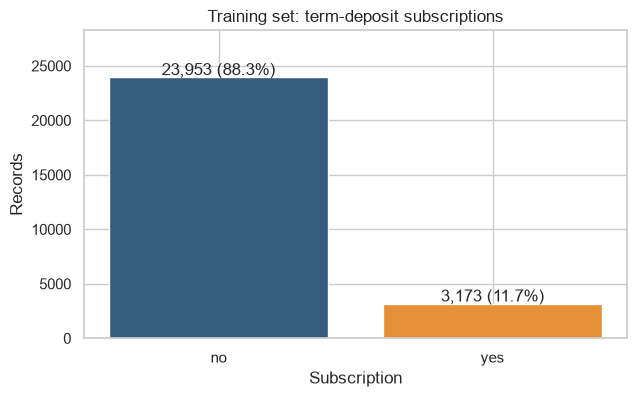

In [5]:
counts = train.y.value_counts().reindex(['no','yes'])
rate = train.response.mean()
print(f'Training positive rate: {rate:.2%}; majority-only accuracy: {1-rate:.2%}; majority-only positive recall: 0%')
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(counts.index,counts.values,color=['#355C7D','#E59036'])
for i,v in enumerate(counts): ax.text(i,v+200,f'{v:,} ({v/len(train):.1%})',ha='center')
ax.set(title='Training set: term-deposit subscriptions',ylabel='Records',xlabel='Subscription'); ax.set_ylim(0,counts.max()*1.18)
savefig('01_target_balance')


## 5. Numeric distributions and outliers
Raw histograms retain legitimate extremes. IQR flags are diagnostic, not removal rules. Negative balances can be valid. Exclude sentinel `pdays=-1` when summarising elapsed days. `day` is calendar information, so its IQR flags are not business anomalies.

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
age,27126.0,40.852393,10.636893,18.0,23.0,33.0,39.0,48.00,59.0,71.00,95.0
balance,27126.0,1361.175035,3053.628721,-8019.0,-626.0,74.0,449.0,1425.00,5763.0,13159.00,102127.0
day,27126.0,15.781132,8.320549,1.0,2.0,8.0,16.0,21.00,29.0,31.00,31.0
duration,27126.0,258.993770,260.659786,0.0,11.0,103.0,180.0,317.75,761.0,1278.25,4918.0
campaign,27126.0,2.750276,3.063629,1.0,1.0,1.0,2.0,3.00,8.0,16.00,63.0
pdays,4897.0,225.715744,114.396706,1.0,8.0,135.0,196.0,329.00,370.0,520.04,871.0
previous,27126.0,0.582393,2.572319,0.0,0.0,0.0,0.0,0.00,3.0,9.00,275.0


,feature,iqr_low,iqr_high,flag_count,skew
0,age,10.500,70.500,297,0.706297
1,balance,-1952.500,3451.500,2866,8.613740
2,day,-11.500,40.500,0,0.098508
3,duration,-219.125,639.875,2009,3.278843
4,campaign,-2.000,6.000,1840,5.022469
5,pdays,-156.000,620.000,27,0.619614
6,previous,0.000,0.000,4897,48.538407


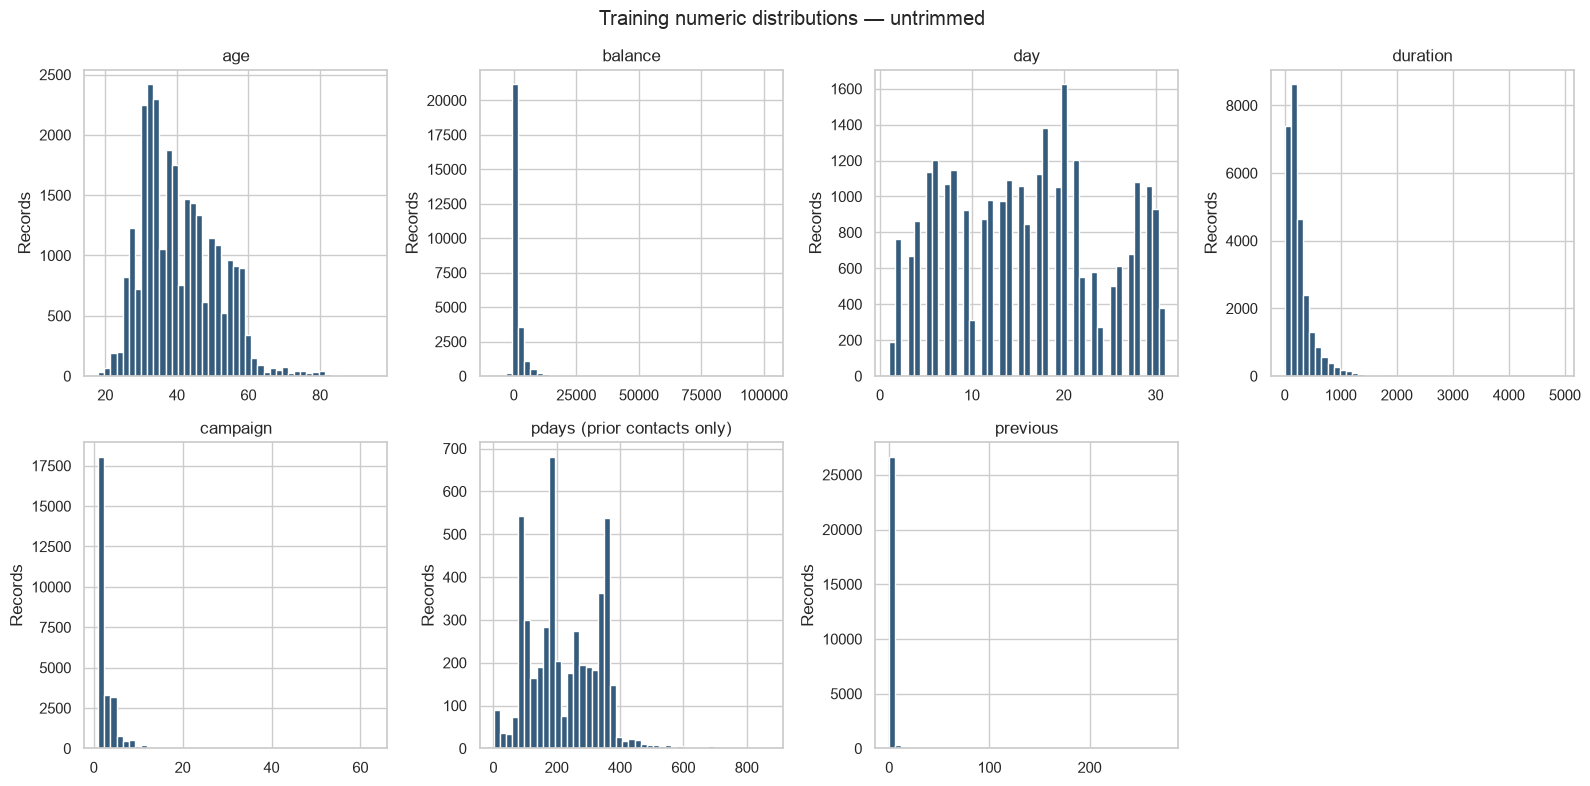

In [6]:
numeric_view = train[num_cols].copy()
numeric_view.loc[numeric_view.pdays.eq(-1),'pdays'] = np.nan
table(numeric_view.describe(percentiles=[.01,.25,.5,.75,.95,.99]).T, 'numeric_summary')
flags=[]
for c in num_cols:
    s = numeric_view[c].dropna(); q1,q3=s.quantile([.25,.75]); iqr=q3-q1
    flags.append({'feature':c,'iqr_low':q1-1.5*iqr,'iqr_high':q3+1.5*iqr,'flag_count':int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()),'skew':s.skew()})
table(pd.DataFrame(flags), 'outlier_flags')
fig, axes = plt.subplots(2,4,figsize=(16,8))
for c,ax in zip(num_cols,axes.flat):
    ax.hist(numeric_view[c].dropna(),bins=45,color='#355C7D'); ax.set_title(c + (' (prior contacts only)' if c=='pdays' else '')); ax.set_ylabel('Records')
axes.flat[-1].axis('off'); fig.suptitle('Training numeric distributions — untrimmed'); fig.tight_layout()
savefig('02_numeric_distributions')


## 6. Categorical segments: support, response and uncertainty
Wilson 95% intervals describe sampling uncertainty under an independent-record approximation; repeated customers could make intervals too narrow. These are exploratory associations, not causal effects or fairness verdicts. Low-support categories are visibly flagged rather than used to justify augmentation automatically.

,n,positives,rate,ci_low,ci_high,low_support
job,,,,,,
student,583,173,0.296741,0.261087,0.335056,False
retired,1367,299,0.218727,0.197618,0.241413,False
unemployed,790,121,0.153165,0.129733,0.179953,False
management,5559,784,0.141033,0.132131,0.150430,False
unknown,176,23,0.130682,0.088682,0.188460,False
admin.,3146,390,0.123967,0.112908,0.135943,False
self-employed,906,99,0.109272,0.090582,0.131260,False
technician,4577,487,0.106402,0.097796,0.115667,False
services,2488,231,0.092846,0.082061,0.104886,False


,n,positives,rate,ci_low,ci_high,low_support
marital,,,,,,
single,7705,1159,0.150422,0.142614,0.158578,False
divorced,3113,383,0.123032,0.111956,0.135038,False
married,16308,1631,0.100012,0.095501,0.104712,False


,n,positives,rate,ci_low,ci_high,low_support
education,,,,,,
tertiary,7902,1194,0.151101,0.143374,0.159167,False
unknown,1135,143,0.125991,0.107938,0.146567,False
secondary,13891,1473,0.106040,0.101028,0.111269,False
primary,4198,363,0.086470,0.078341,0.095354,False


,n,positives,rate,ci_low,ci_high,low_support
default,,,,,,
no,26642,3145,0.118047,0.114227,0.121976,False
yes,484,28,0.057851,0.040325,0.082341,False


,n,positives,rate,ci_low,ci_high,low_support
housing,,,,,,
no,12029,1997,0.166015,0.159473,0.172771,False
yes,15097,1176,0.077896,0.073728,0.082280,False


,n,positives,rate,ci_low,ci_high,low_support
loan,,,,,,
no,22756,2868,0.126033,0.121784,0.130408,False
yes,4370,305,0.069794,0.062611,0.077733,False


,n,positives,rate,ci_low,ci_high,low_support
contact,,,,,,
cellular,17577,2620,0.149058,0.143870,0.154400,False
telephone,1736,236,0.135945,0.120624,0.152873,False
unknown,7813,317,0.040573,0.036419,0.045179,False


,n,positives,rate,ci_low,ci_high,low_support
month,,,,,,
mar,290,145,0.500000,0.442830,0.557170,False
dec,140,65,0.464286,0.383731,0.546748,False
sep,331,150,0.453172,0.400386,0.507033,False
oct,458,202,0.441048,0.396252,0.486825,False
apr,1781,344,0.193150,0.175484,0.212137,False
feb,1571,272,0.173138,0.155231,0.192640,False
aug,3715,399,0.107402,0.097848,0.117768,False
nov,2346,246,0.104859,0.093101,0.117910,False
jan,851,89,0.104583,0.085769,0.126951,False


,n,positives,rate,ci_low,ci_high,low_support
poutcome,,,,,,
success,901,566,0.628191,0.596152,0.659142,False
other,1111,177,0.159316,0.138975,0.182005,False
failure,2880,348,0.120833,0.109432,0.133245,False
unknown,22234,2082,0.093640,0.089881,0.097540,False


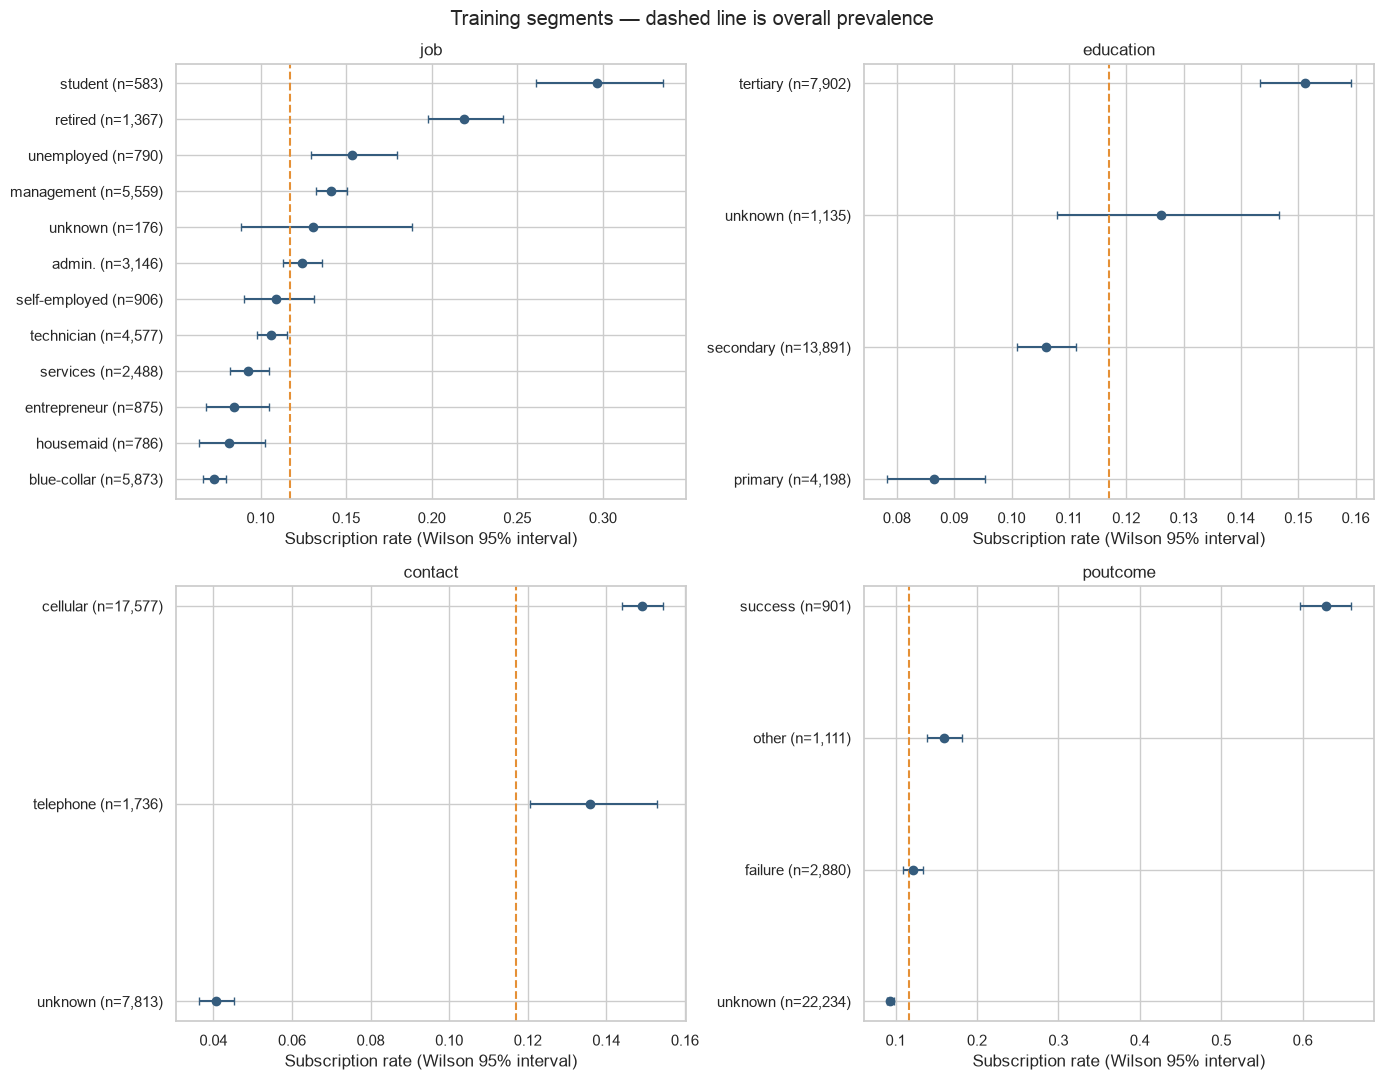

,feature,category,n,positives,rate


,n,positives,rate,ci_low,ci_high,low_support
age_band,,,,,,
60+,1069,346,0.323667,0.296294,0.352303,False
<30,3268,577,0.176561,0.163869,0.190011,False
30–39,10802,1159,0.107295,0.101597,0.113272,False
40–49,7021,658,0.093719,0.087122,0.100760,False
50–59,4966,433,0.087193,0.079662,0.095362,False


In [7]:
def segments(frame, col):
    g=frame.groupby(col,observed=True).response.agg(n='size',positives='sum',rate='mean')
    z=1.96; p=g.rate; nn=g.n
    center=(p+z*z/(2*nn))/(1+z*z/nn)
    half=z*np.sqrt(p*(1-p)/nn+z*z/(4*nn*nn))/(1+z*z/nn)
    g['ci_low']=center-half; g['ci_high']=center+half
    g['low_support']=(g.n<100)|(g.positives<20)
    return g.sort_values('rate',ascending=False)
segment_tables={c:segments(train,c) for c in cat_cols}
for c,g in segment_tables.items(): table(g, 'segment_'+c)
fig,axes=plt.subplots(2,2,figsize=(14,11))
for c,ax in zip(['job','education','contact','poutcome'],axes.flat):
    g=segment_tables[c].sort_values('rate'); yy=np.arange(len(g))
    ax.errorbar(g.rate,yy,xerr=[g.rate-g.ci_low,g.ci_high-g.rate],fmt='o',color='#355C7D',capsize=3)
    ax.set_yticks(yy, [f'{k} (n={int(v):,})' for k,v in g.n.items()]); ax.axvline(rate,color='#E59036',linestyle='--')
    ax.set(title=c,xlabel='Subscription rate (Wilson 95% interval)')
fig.suptitle('Training segments — dashed line is overall prevalence'); fig.tight_layout()
savefig('03_segment_response')
rare = pd.concat([g.assign(feature=c,category=g.index).reset_index(drop=True) for c,g in segment_tables.items()],ignore_index=True)
table(rare[rare.low_support][['feature','category','n','positives','rate']], 'low_support_categories')
train['age_band'] = pd.cut(train.age,[0,30,40,50,60,np.inf],right=False,labels=['<30','30–39','40–49','50–59','60+'])
table(segments(train,'age_band'), 'segment_age_band')


## 7. Relationships and campaign patterns
Spearman correlation handles skewed numeric variables, but integer calendar days are not elapsed time. Cramér's V captures categorical dependence without implying direction or causality. Neither is a feature-selection rule. Campaign contacts and call length can be consequences of campaign process; confirm availability at the intended decision point.

,age,balance,day,duration,campaign,pdays,previous,response
age,1.000000,0.090202,-0.008813,-0.038471,0.044968,-0.074434,-0.019182,-0.016765
balance,0.090202,1.000000,0.001839,0.039898,-0.034670,-0.194967,0.080833,0.104282
day,-0.008813,0.001839,1.000000,-0.056768,0.135735,-0.089499,-0.087656,-0.029776
duration,-0.038471,0.039898,-0.056768,1.000000,-0.108057,-0.038413,0.025875,0.341927
campaign,0.044968,-0.034670,0.135735,-0.108057,1.000000,0.077516,-0.111133,-0.079938
pdays,-0.074434,-0.194967,-0.089499,-0.038413,0.077516,1.000000,-0.094623,-0.190725
previous,-0.019182,0.080833,-0.087656,0.025875,-0.111133,-0.094623,1.000000,0.157816
response,-0.016765,0.104282,-0.029776,0.341927,-0.079938,-0.190725,0.157816,1.000000


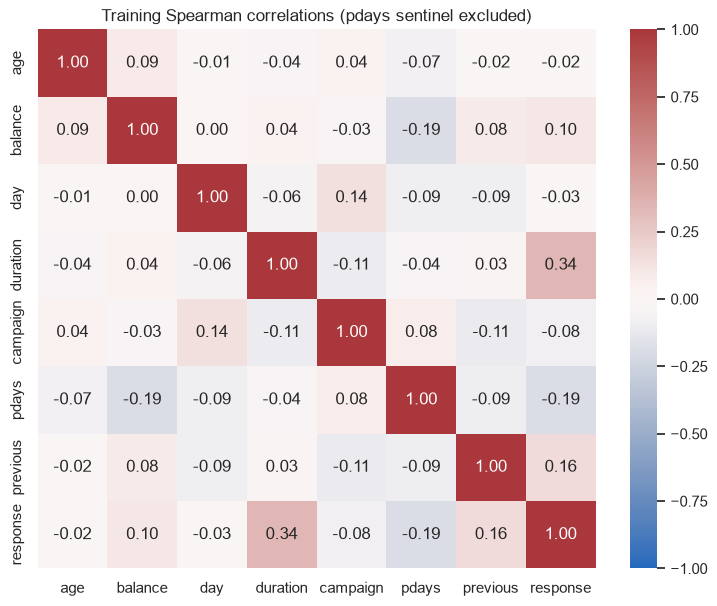

,job,marital,education,default,housing,loan,contact,month,poutcome,y
job,1.000000,0.208196,0.458616,0.023112,0.283332,0.108463,0.156708,0.111857,0.063455,0.135767
marital,0.208196,1.000000,0.118874,0.022802,0.019886,0.052802,0.043541,0.065812,0.029868,0.068690
education,0.458616,0.118874,1.000000,0.017650,0.111681,0.076682,0.120873,0.108826,0.036676,0.072070
default,0.023112,0.022802,0.017650,1.000000,0.000000,0.077050,0.024935,0.057691,0.035860,0.024040
housing,0.283332,0.019886,0.111681,0.000000,1.000000,0.040703,0.215473,0.505120,0.143004,0.136079
loan,0.108463,0.052802,0.076682,0.077050,0.040703,1.000000,0.014818,0.188598,0.058889,0.064043
contact,0.156708,0.043541,0.120873,0.024935,0.215473,0.014818,1.000000,0.511891,0.206479,0.151277
month,0.111857,0.065812,0.108826,0.057691,0.505120,0.188598,0.511891,1.000000,0.212814,0.257045
poutcome,0.063455,0.029868,0.036676,0.035860,0.143004,0.058889,0.206479,0.212814,1.000000,0.298296
y,0.135767,0.068690,0.072070,0.024040,0.136079,0.064043,0.151277,0.257045,0.298296,1.000000


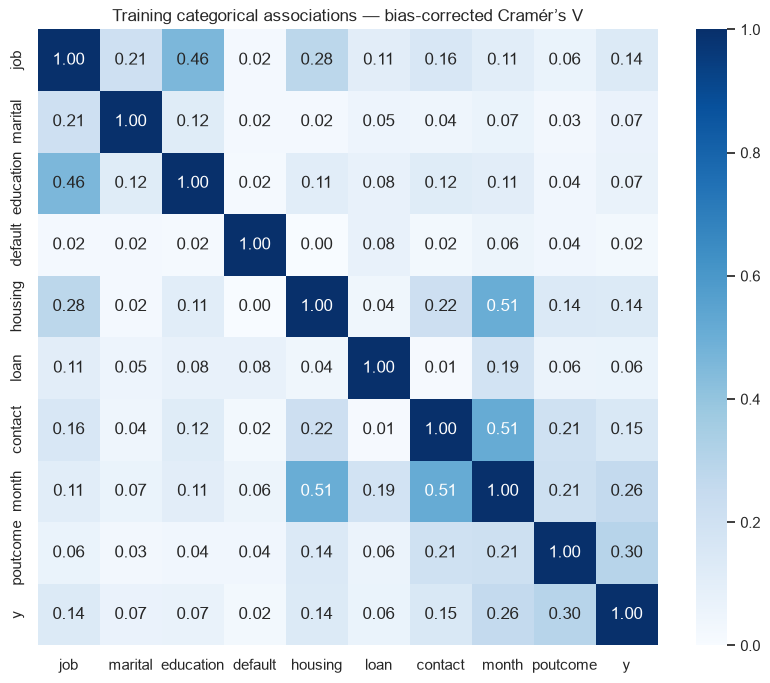

,n,positives,rate,ci_low,ci_high,low_support
campaign_band,,,,,,
1,10519,1523,0.144786,0.138191,0.151640,False
3,3322,373,0.112282,0.101990,0.123469,False
2,7541,839,0.111258,0.104358,0.118555,False
4–5,3158,287,0.090880,0.081346,0.101409,False
6–10,1882,118,0.062699,0.052612,0.074568,False
11+,704,33,0.046875,0.033570,0.065099,False


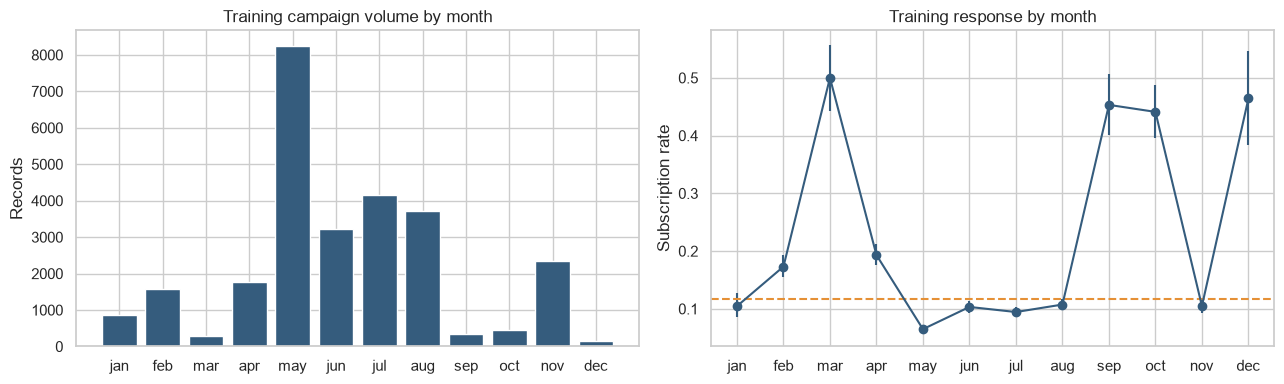

In [8]:
corr = numeric_view.assign(response=train.response).corr(method='spearman')
table(corr, 'spearman')
fig,ax=plt.subplots(figsize=(9,7)); sns.heatmap(corr,annot=True,fmt='.2f',vmin=-1,vmax=1,cmap='vlag',ax=ax)
ax.set_title('Training Spearman correlations (pdays sentinel excluded)'); savefig('04_spearman')
def cramers_v(a,b):
    ct=pd.crosstab(a,b)
    if min(ct.shape)<2: return np.nan
    chi=chi2_contingency(ct,correction=False)[0]; nn=ct.values.sum(); r,k=ct.shape
    phi=max(0,chi/nn-((k-1)*(r-1))/(nn-1))
    denom=min(k-1-(k-1)**2/(nn-1),r-1-(r-1)**2/(nn-1))
    return np.sqrt(phi/denom) if denom>0 else np.nan
assoc_cols=cat_cols+['y']
vmat=pd.DataFrame([[1. if a==b else cramers_v(train[a],train[b]) for b in assoc_cols] for a in assoc_cols],index=assoc_cols,columns=assoc_cols)
table(vmat, 'cramers_v')
fig,ax=plt.subplots(figsize=(10,8)); sns.heatmap(vmat,annot=True,fmt='.2f',vmin=0,vmax=1,cmap='Blues',ax=ax); ax.set_title('Training categorical associations — bias-corrected Cramér’s V'); savefig('05_categorical_associations')
train['campaign_band']=pd.cut(train.campaign,[0,1,2,3,5,10,np.inf],labels=['1','2','3','4–5','6–10','11+'])
table(segments(train,'campaign_band'), 'segment_campaign_band')
months=['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
m=segment_tables['month'].reindex(months)
fig,axes=plt.subplots(1,2,figsize=(13,4)); axes[0].bar(months,m.n,color='#355C7D'); axes[1].errorbar(months,m.rate,yerr=[m.rate-m.ci_low,m.ci_high-m.rate],fmt='o-',color='#355C7D'); axes[1].axhline(rate,color='#E59036',linestyle='--')
axes[0].set(title='Training campaign volume by month',ylabel='Records'); axes[1].set(title='Training response by month',ylabel='Subscription rate')
fig.tight_layout(); savefig('06_month_patterns')


## 8. Leakage and treatment recommendations
`duration` is only known after the call and must be excluded for a pre-call targeting model, even if it is associated strongly with `y`. Keep it for a labelled descriptive chart only. `campaign` includes the last contact: a next-call decision and first-call decision have different available information. The draft proposes imputing true gaps by a 5% threshold; EDA does not establish that these unknowns are true gaps or that this threshold is optimal.

For `pdays`, keep `previously_contacted` plus a numeric value missing only for the no-history state. A later training-fitted imputer can fill the numeric component while retaining the flag. No transformations are fitted to validation/test here.

Duration medians by response (descriptive, excluded from model):


,count,median,mean
y,,,
no,23953,164.0,221.221308
yes,3173,429.0,544.138355


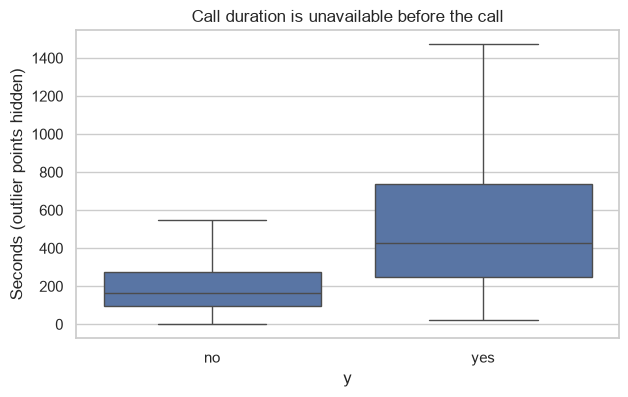

,column,train_unknown_count,proposed_action,reason,status
0,age,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment
1,job,176,Restore/retain unknown category in baseline; t...,Source unknown does not establish missing-at-r...,recommendation; not a fitted treatment
2,marital,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment
3,education,1135,Restore/retain unknown category in baseline; t...,Source unknown does not establish missing-at-r...,recommendation; not a fitted treatment
4,default,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment
5,balance,0,Retain; encode categories or scale numeric fie...,Negative balances and large values may be vali...,recommendation; not a fitted treatment
6,housing,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment
7,loan,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment
8,contact,7813,Restore/retain unknown category in baseline; t...,Source unknown does not establish missing-at-r...,recommendation; not a fitted treatment
9,day,0,Retain; encode categories or scale numeric fie...,No automatic deletion or statistical imputatio...,recommendation; not a fitted treatment


Proposed pre-call schema: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']


In [9]:
print('Duration medians by response (descriptive, excluded from model):')
display(train.groupby('y').duration.agg(['count','median','mean']))
fig,ax=plt.subplots(figsize=(7,4)); sns.boxplot(data=train,x='y',y='duration',showfliers=False,ax=ax); ax.set(title='Call duration is unavailable before the call',ylabel='Seconds (outlier points hidden)'); savefig('07_duration_leakage')
treatments=[]
for c in expected:
    action='Retain; encode categories or scale numeric fields in later train-fitted pipeline'
    reason='No automatic deletion or statistical imputation during EDA'
    if c in ['job','education','contact']: action='Restore/retain unknown category in baseline; test imputation as a separate Arm B policy'; reason='Source unknown does not establish missing-at-random; preserve missingness information'
    if c=='poutcome': action='Retain unknown as informative no/unknown-history state'; reason='Review jointly with pdays and previous; avoid inventing prior success/failure'
    if c=='pdays': action='Derive previously_contacted and sentinel-free pdays; impute later on train only'; reason='-1 denotes no prior contact, not an elapsed-day outlier'
    if c=='duration': action='Exclude from primary pre-call model and GAN modelling schema'; reason='Post-call availability leaks information for pre-call targeting'
    if c in ['campaign','day','month','contact']: reason += '; confirm availability at prediction time'
    if c=='balance': reason='Negative balances and large values may be valid; retain unless business rule justifies treatment'
    if c=='y': action='Target only; condition CTGAN on y in later experiments'; reason='Never include target among predictive features'
    treatments.append({'column':c,'train_unknown_count':int(profile.loc[c,'train_unknown']),'proposed_action':action,'reason':reason,'status':'recommendation; not a fitted treatment'})
table(pd.DataFrame(treatments), 'proposed_treatment_log')
eda_features=train[expected].drop(columns=['duration','y']).copy()
eda_features['previously_contacted']=eda_features.pdays.ne(-1).astype(int)
eda_features['pdays']=eda_features.pdays.replace(-1,np.nan)
print('Proposed pre-call schema:', eda_features.columns.tolist())
